# Advención 1D:

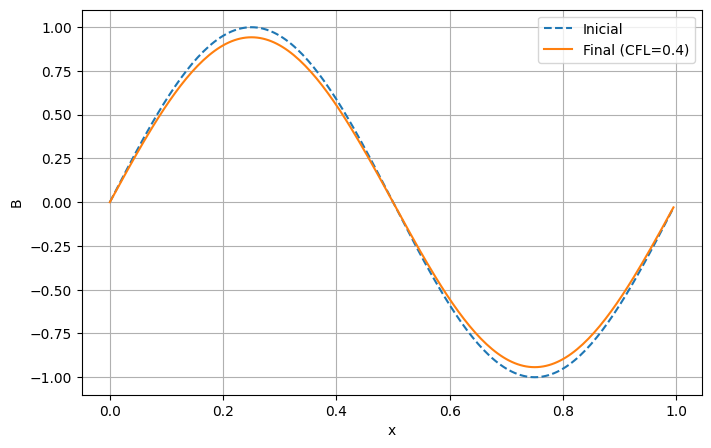

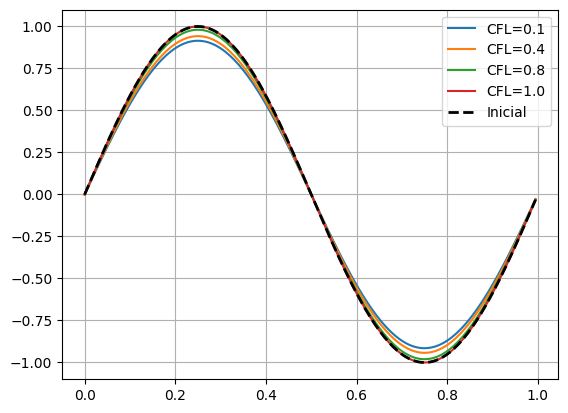

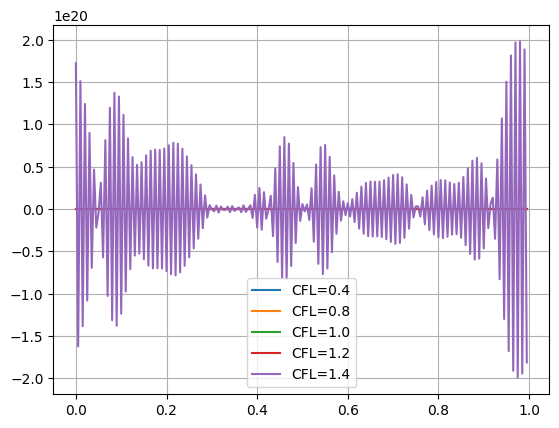

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N = 200
L = 1.0
v0 = 1.0

dx = L / N

# CFL que se desea probar
CFL = 0.4

dt = CFL * dx / v0

#Tiempo total de simulacion
tmax = 1.0

nsteps = int(tmax / dt)

# Malla
x = np.linspace(0, L, N, endpoint=False)

# CONDICION INICIAL

# Onda sinusoidal
B0 = np.sin(2*np.pi*x/L)

# EVOLUCION
B = B0.copy()

for n in range(nsteps):

    # diferencia hacia atras
    backward = B - np.roll(B, 1)

    # esquema upwind
    B = B - CFL*backward

#Gráfica incial
plt.figure(figsize=(8,5))
plt.plot(x, B0, '--', label='Inicial')
plt.plot(x, B, label=f'Final (CFL={CFL})')
plt.xlabel('x')
plt.ylabel('B')
plt.legend()
plt.grid()
plt.show()

#Gráfica con variaciones de CFL 
CFL_list = [0.1, 0.4, 0.8, 1.0]

for CFL in [0.1,0.4,0.8,1.0]:

    dt = CFL*dx/v0
    nsteps = int(tmax/dt)

    B = B0.copy()

    for n in range(nsteps):
        backward = B - np.roll(B,1)
        B = B - CFL*backward

    plt.plot(x,B,label=f'CFL={CFL}')

plt.plot(x,B0,'k--',lw=2,label='Inicial')

plt.legend()
plt.grid()
plt.show()

#Gráfica con variaciones de CFL > 1 
for CFL in [0.4,0.8,1.0,1.2,1.4]:

    dt = CFL*dx/v0
    nsteps = int(tmax/dt)

    B = B0.copy()

    for n in range(nsteps):
        backward = B - np.roll(B,1)
        B = B - CFL*backward

    plt.plot(x,B,label=f'CFL={CFL}')

plt.legend()
plt.grid()
plt.show()



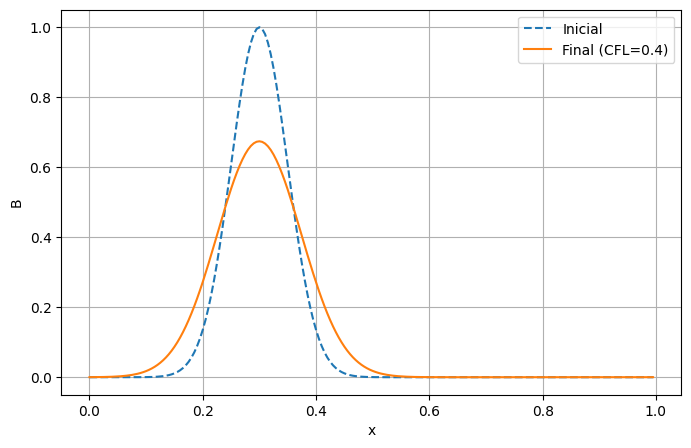

In [ ]:
#Dejo esta gráfica aparte con el mismo código solo cambiando la condición inicial a un pulso gaussiano para que no se mezcle con la lógica del código principal

import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N = 200
L = 1.0
v0 = 1.0

dx = L / N

# CFL que se desea probar
CFL = 0.4

dt = CFL * dx / v0

#Tiempo total de simulacion
tmax = 1.0

nsteps = int(tmax / dt)

# Malla
x = np.linspace(0, L, N, endpoint=False)

# CONDICION INICIAL

# Onda sinusoidal
x0 = 0.3
sigma = 0.05

B0 = np.exp(-(x-x0)**2/(2*sigma**2))

# EVOLUCION
B = B0.copy()

for n in range(nsteps):

    # diferencia hacia atras
    backward = B - np.roll(B, 1)

    # esquema upwind
    B = B - CFL*backward

#Gráfica del pulso
plt.figure(figsize=(8,5))
plt.plot(x, B0, '--', label='Inicial')
plt.plot(x, B, label=f'Final (CFL={CFL})')
plt.xlabel('x')
plt.ylabel('B')
plt.legend()
plt.grid()
plt.show()

### ¿Cómo es el perfil de la onda?
La onda se desplaza con velocidad $v_0$ hacia la derecha, la solución exacta sería:

$$B(x,t) = B(x - v_0t, 0)$$

sin cambiar forma ni amplitud. Sin embargo, el esquema upwind introduce difusión numérica, por lo que la amplitud disminuye lentamente.

### ¿Cómo es el perfil si CFL es cercano a cero?
Cuando

$$CFL \ll 1$$

el método es muy difusivo, podemos ver una amplitud menor, crestas o picos más suaves y pérdida de detalles, es como si la onda se "desparramara".

### ¿Cómo es el perfil si CFL es cercano a 1?
Cuando

$$CFL \approx 1$$

el método es mucho más preciso, la onda conserva mejor su amplitud, mantiene mejor la forma y presenta menos difusión numérica. De hecho, para una advección lineal simple, $CFL = 1$ es prácticamente el mejor caso para este esquema.

### ¿Qué pasa cuando CFL > 1?
Se viola el criterio de estabilidad y aparecen oscilaciones no físicas (artificiales o por artifacs), amplitudes crecientes y sobre todo una explosión numérica.

### ¿Cómo cambia si hay un pulso gaussiano?
El pulso simplemente se transporta:

$$B(x,t) = B(x - v_0t)$$

pero debido a la difusión numérica el pico disminuye, por consecuencia el ancho aumenta y eso hace que la gaussiana se vuelve más plana. El efecto es mucho más visible para CFL pequeños.

# FEM para la ecuación de Poisson gravitacional 1D:

### 1. Reformular como problema variacional (forma débil)
La ecuación dada es:

$$\frac{1}{r^2} \frac{d}{dr} \left( r^2 \frac{d\Phi}{dr} \right) = 4\pi G \rho(r)$$

con

$$\rho(r) = \rho_c \left( 1 - \frac{r^2}{R^2} \right).$$

### Paso 1.1: Multiplicar por una función de prueba
Sea $v(r)$ una función de prueba.

Multiplicamos:

$$\int_{0}^{R} v \frac{1}{r^2} \frac{d}{dr} \left( r^2 \frac{d\Phi}{dr} \right) dr = 4\pi G \int_{0}^{R} \rho(r) v(r) dr.$$

Multiplicamos por $r^2$:

$$\int_{0}^{R} v \frac{d}{dr} \left( r^2 \frac{d\Phi}{dr} \right) dr = 4\pi G \int_{0}^{R} \rho(r) r^2 v dr.$$

### Paso 1.2: Integración por partes
Aplicando integración por partes:

$$\left[ v r^2 \frac{d\Phi}{dr} \right]_{0}^{R} - \int_{0}^{R} r^2 \frac{d\Phi}{dr} \frac{dv}{dr} dr = 4\pi G \int_{0}^{R} \rho r^2 v dr.$$

Suponiendo:

$$v(R) = 0$$

y regularidad en $r = 0$, el término de borde desaparece, tenemos entonces:

$$\int_{0}^{R} r^2 \frac{d\Phi}{dr} \frac{dv}{dr} dr = -4\pi G \int_{0}^{R} \rho(r) r^2 v(r) dr.$$

la forma debíl (final)

$$a(\Phi, v) = L(v)$$

con

$$a(\Phi, v) = \int_{0}^{R} r^2 \Phi' v' dr$$

y

$$L(v) = -4\pi G \int_{0}^{R} \rho(r) r^2 v dr.$$

Esta es la ecuación que discretizaremos.

### 2. Implementar FEM con n = 10,20,40 elementos lineales
Para elementos lineales:

$$\Phi(r) = \sum_{j} \Phi_j N_j(r).$$

La matriz elemental es

$$K^{(e)} = \int_{r_e}^{r_{e+1}} r^2 \frac{dN_i}{dr} \frac{dN_j}{dr} dr.$$

Como

$$\frac{dN_1}{dr} = -\frac{1}{h}, \quad \frac{dN_2}{dr} = +\frac{1}{h},$$

obtenemos

$$K^{(e)} = \frac{1}{h^2} \left( \int_{r_e}^{r_{e+1}} r^2 dr \right) \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}.$$

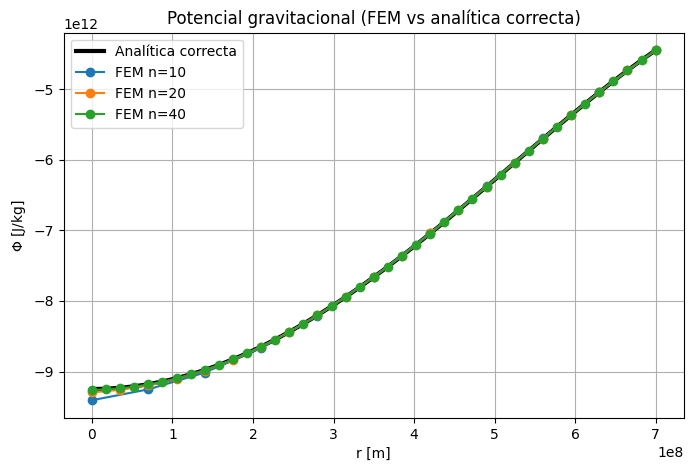

Errores RMSE respecto a la analítica CORRECTA:
n= 10  RMSE=5.463e+10
n= 20  RMSE=1.378e+10
n= 40  RMSE=3.410e+09

Gravedad superficial numérica (n=40): -8011.93 m/s²
Gravedad superficial analítica:      -8016.44 m/s²
Valor solar de referencia:           274.0 m/s²


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
G = 6.67430e-11
rho_c = 1e5
R = 7e8

# Densidad
def rho(r):
    return rho_c * (1 - r**2 / R**2)

# Solución analítica CORRECTA (cumple 4πG)
def phi_exact_correct(r):
    # phi(R) según la expresión original (para mantener la misma condición Dirichlet)
    phiR = -2 * np.pi * G * rho_c * (R**2/3 - R**2/6 + R**4/(20*R**2))
    # Solución general de 4πGρ: A + (2π/3)Gρc r^2 - (π/5)Gρc r^4/R^2
    A = phiR - (2*np.pi/3)*G*rho_c*R**2 + (np.pi/5)*G*rho_c*R**2
    return A + (2*np.pi/3)*G*rho_c * r**2 - (np.pi/5)*G*rho_c * r**4 / R**2

# Solución analítica original (errónea) – la dejo por si quieres comparar
def phi_exact_original(r):
    return -2 * np.pi * G * rho_c * (R**2/3 - r**2/6 + r**4/(20*R**2))

# FEM
def solve_fem(ne):
    nodes = np.linspace(0, R, ne+1)
    K = np.zeros((ne+1, ne+1))
    F = np.zeros(ne+1)

    for e in range(ne):
        r1 = nodes[e]
        r2 = nodes[e+1]
        h = r2 - r1
        rm = 0.5 * (r1 + r2)          # punto medio para cuadratura

        # ∫ r² dr en el elemento
        int_r2 = (r2**3 - r1**3) / 3

        # matriz elemental
        Ke = (int_r2 / h**2) * np.array([[1, -1],
                                         [-1, 1]])

        # vector elemental: -4πG ∫ ρ v r² dr  (punto medio)
        fe = (-4 * np.pi * G * rho(rm) * rm**2 * h / 2) * np.ones(2)

        idx = [e, e+1]
        for i in range(2):
            for j in range(2):
                K[idx[i], idx[j]] += Ke[i, j]
        F[idx] += fe

    # Condición Dirichlet en r=R usando la solución correcta
    phiR = phi_exact_correct(R)
    F -= K[:, -1] * phiR
    K[-1, :] = 0
    K[:, -1] = 0
    K[-1, -1] = 1
    F[-1] = phiR

    Phi = np.linalg.solve(K, F)
    return nodes, Phi

# Cálculo de la aceleración de gravedad superficial
def gravity_surface(ne):
    r, Phi = solve_fem(ne)
    # derivada en el último elemento (lineal)
    h = r[-1] - r[-2]
    g_num = -(Phi[-1] - Phi[-2]) / h   # -dΦ/dr
    # valor analítico correcto
    g_exact = -np.gradient(phi_exact_correct(r), r)
    return g_num, g_exact[-1]

#COMPARACIÓN GRÁFICA
plt.figure(figsize=(8, 5))
r_exact = np.linspace(0, R, 1000)
plt.plot(r_exact, phi_exact_correct(r_exact), 'k', lw=3, label='Analítica correcta')
for ne in [10, 20, 40]:
    r, Phi = solve_fem(ne)
    plt.plot(r, Phi, 'o-', label=f'FEM n={ne}')
plt.xlabel('r [m]')
#plt.ylabel('$\Phi$ [J/kg]')
plt.ylabel(r'$\Phi$ [J/kg]')
plt.legend()
plt.grid()
plt.title('Potencial gravitacional (FEM vs analítica correcta)')
plt.show()

#ERRORES
print("Errores RMSE respecto a la analítica CORRECTA:")
for ne in [10, 20, 40]:
    r, Phi = solve_fem(ne)
    err = np.sqrt(np.mean((Phi - phi_exact_correct(r))**2))
    print(f"n={ne:3d}  RMSE={err:.3e}")

#GRAVEDAD SUPERFICIAL
g_num, g_ex = gravity_surface(40)
print(f"\nGravedad superficial numérica (n=40): {g_num:.2f} m/s²")
print(f"Gravedad superficial analítica:      {g_ex:.2f} m/s²")
print(f"Valor solar de referencia:           274.0 m/s²")

### Calcular la gravedad superficial
La aceleración gravitacional es:

$$g(r) = -\frac{d\Phi}{dr}.$$

Nos piden evaluarla en: 

$$r = R.$$

### Derivada analítica
Partimos de;

$$\Phi(r) = -4\pi G \rho_c \left( \frac{R^2}{3} - \frac{r^2}{6} + \frac{r^4}{20R^2} \right)$$

Derivando:

$$\frac{d\Phi}{dr} = -4\pi G \rho_c \left( -\frac{r}{3} + \frac{r^3}{5R^2} \right)$$

Entonces tenemos:

$$g(R) = 4\pi G \rho_c \left( -\frac{R}{3} + \frac{R}{5} \right)$$

$$g(R) = -\frac{8\pi}{15} G \rho_c R$$

Tomando magnitud:

$$|g(R)| = \frac{8\pi}{15} G \rho_c R$$

Luego: 

$$|g(R)| \approx 7830 \text{ m/s}^2$$

### Comparación con Sol 
La gravedad superficial solar es:

$$g_{\odot} \approx 274 \text{ m/s}^2$$

Por tanto con el valor numérico:

$$\frac{g(R)}{g_{\odot}} \approx 29.3$$

La estrella politrópica propuesta tiene una gravedad superficial aproximadamente 29 veces mayor que la del Sol. 

Por otro lado con el valor analítico: 

$$\frac{g(R)}{g_{\odot}} \approx 28.6$$

LOKURA

# Potencial Gravitacional en un disco Protoplanetario:

## 1. Discretización y condiciones de frontera

La ecuación de Poisson en coordenadas cilíndricas con simetría axial (independencia de $\phi$):

$$\frac{\partial^2\Phi}{\partial r^2} + \frac{1}{r} \frac{\partial\Phi}{\partial r} + \frac{\partial^2\Phi}{\partial z^2} = 4\pi G\rho(r, z)$$

Discretizamos en una malla uniforme $r_i = i\Delta r$ ($i = 0, \dots, N_r - 1$), $z_j = j\Delta z$ ($j = 0, \dots, N_z - 1$), con

$$\Delta r = \frac{R_{\text{max}}}{N_r - 1}, \quad \Delta z = \frac{Z_{\text{max}}}{N_z - 1}.$$

* **Para puntos interiores** ($i = 1, \dots, N_r - 2, \, j = 1, \dots, N_z - 2$) usamos diferencias centradas:

$$\frac{\Phi_{i+1,j} - 2\Phi_{i,j} + \Phi_{i-1,j}}{\Delta r^2} + \frac{1}{r_i}\frac{\Phi_{i+1,j} - \Phi_{i-1,j}}{2\Delta r} + \frac{\Phi_{i,j+1} - 2\Phi_{i,j} + \Phi_{i,j-1}}{\Delta z^2} = 4\pi G \rho_{i,j}.$$

* En el **eje** ($i = 0, \, r = 0$) la singularidad $1/r$ se resuelve por simetría: $\partial\Phi/\partial r|_{r=0} = 0$ y usando L'Hôpital, la ecuación se reduce a

$$2\frac{\partial^2\Phi}{\partial r^2} + \frac{\partial^2\Phi}{\partial z^2} = 4\pi G\rho.$$

Discretizando con $\Phi_{-1,j} = \Phi_{1,j}$ obtenemos, para $j = 1, \dots, N_z - 2$:

$$\frac{4(\Phi_{1,j} - \Phi_{0,j})}{\Delta r^2} + \frac{\Phi_{0,j+1} - 2\Phi_{0,j} + \Phi_{0,j-1}}{\Delta z^2} = 4\pi G \rho_{0,j}.$$

* **Condiciones de frontera:**
$\Phi = 0$ en los bordes exteriores: $r = R_{\text{max}}$ ($i = N_r - 1$), $z = 0$ ($j = 0$) y $z = Z_{\text{max}}$ ($j = N_z - 1$).
El eje $r = 0$ se trata con la fórmula especial anterior; no se impone Dirichlet.

## 2. Implementación de Gauss-Seidel y SOR

Se resuelve el sistema por método iterativo. Partiendo de una estimación inicial $\Phi = 0$, en cada iteración se actualiza cada punto interior usando el esquema correspondiente.
En **SOR**, la actualización se acelera con un factor de relajación $\lambda$:

$$\Phi_{i,j}^{\text{new}} = (1 - \lambda) \Phi_{i,j}^{\text{old}} + \lambda \Phi_{i,j}^{\text{GS}},$$

donde $\Phi_{i,j}^{\text{GS}}$ es el valor que daría una iteración de Gauss-Seidel.

El criterio de convergencia es un error relativo máximo menor a $0.1\%$:

$$\max_{i,j} \left| \frac{\Phi_{i,j}^{\text{new}} - \Phi_{i,j}^{\text{old}}}{\Phi_{i,j}^{\text{new}}} \right| < 10^{-3}.$$

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Parámetros físicos y geométricos
AU = 1.496e11  # m
Rmax = 10 * AU
Zmax = 2 * AU
r0 = 3 * AU
h = 0.5 * AU
rho0_SI = 1e-6  # kg/m^3 (1e-9 g/cm^3)
G = 6.67430e-11

# Malla
Nr, Nz = 50, 20
dr = Rmax / (Nr - 1)
dz = Zmax / (Nz - 1)

r = np.linspace(0, Rmax, Nr)
z = np.linspace(0, Zmax, Nz)
R, Z = np.meshgrid(r, z, indexing='ij')  # R(i,j), Z(i,j)

# Densidad
rho = rho0_SI * np.exp(-R / r0) * np.exp(-Z**2 / (2 * h**2))

# Término fuente
src = 4 * np.pi * G * rho

# Factores para las fórmulas iterativas
# Precalcular coeficientes para puntos interiores
# Coeficientes de la discretización:
# A*Phi_{i+1} + B*Phi_{i-1} + C*Phi_{i,j} + D*(Phi_{i,j+1}+Phi_{i,j-1}) = src
# En Gauss-Seidel despejamos Phi_{i,j}
# Interior (i>0, j interior)
inv_dr2 = 1 / dr**2
inv_dz2 = 1 / dz**2

def gauss_seidel_step(Phi, src):
    """Una pasada de Gauss-Seidel, actualiza in-place y devuelve el máximo cambio relativo."""
    max_change = 0.0
    # Puntos interiores i=1..Nr-2, j=1..Nz-2
    for i in range(1, Nr-1):
        ri = r[i]
        for j in range(1, Nz-1):
            old = Phi[i, j]
            # Términos de la discretización
            term_r_plus  = Phi[i+1, j] * (inv_dr2 + 0.5/(ri*dr))
            term_r_minus = Phi[i-1, j] * (inv_dr2 - 0.5/(ri*dr))
            term_z = (Phi[i, j+1] + Phi[i, j-1]) * inv_dz2
            new = (term_r_plus + term_r_minus + term_z - src[i, j]) / (2*inv_dr2 + 2*inv_dz2)
            Phi[i, j] = new
            if np.abs(new) > 1e-20:
                rel = np.abs(new - old) / np.abs(new)
                if rel > max_change:
                    max_change = rel
    # Eje i=0, j=1..Nz-2
    for j in range(1, Nz-1):
        old = Phi[0, j]
        # Ecuación en r=0: 4*(Phi[1,j] - Phi[0,j])/dr^2 + (Phi[0,j+1]-2*Phi[0,j]+Phi[0,j-1])/dz^2 = src
        term_r = 4 * inv_dr2 * Phi[1, j]
        term_z = (Phi[0, j+1] + Phi[0, j-1]) * inv_dz2
        new = (term_r + term_z - src[0, j]) / (4*inv_dr2 + 2*inv_dz2)
        Phi[0, j] = new
        if np.abs(new) > 1e-20:
            rel = np.abs(new - old) / np.abs(new)
            if rel > max_change:
                max_change = rel
    # Bordes Dirichlet (se mantienen en 0)
    return max_change

def sor_step(Phi, src, lam):
    """Una pasada SOR con factor lam."""
    max_change = 0.0
    # Interior i>0
    for i in range(1, Nr-1):
        ri = r[i]
        for j in range(1, Nz-1):
            old = Phi[i, j]
            term_r_plus  = Phi[i+1, j] * (inv_dr2 + 0.5/(ri*dr))
            term_r_minus = Phi[i-1, j] * (inv_dr2 - 0.5/(ri*dr))
            term_z = (Phi[i, j+1] + Phi[i, j-1]) * inv_dz2
            gs = (term_r_plus + term_r_minus + term_z - src[i, j]) / (2*inv_dr2 + 2*inv_dz2)
            new = (1 - lam) * old + lam * gs
            Phi[i, j] = new
            if np.abs(new) > 1e-20:
                rel = np.abs(new - old) / np.abs(new)
                if rel > max_change:
                    max_change = rel
    # Eje i=0
    for j in range(1, Nz-1):
        old = Phi[0, j]
        term_r = 4 * inv_dr2 * Phi[1, j]
        term_z = (Phi[0, j+1] + Phi[0, j-1]) * inv_dz2
        gs = (term_r + term_z - src[0, j]) / (4*inv_dr2 + 2*inv_dz2)
        new = (1 - lam) * old + lam * gs
        Phi[0, j] = new
        if np.abs(new) > 1e-20:
            rel = np.abs(new - old) / np.abs(new)
            if rel > max_change:
                max_change = rel
    return max_change

# Gauss-Seidel puro (lambda=1.0 corresponde a GS)
Phi_gs = np.zeros((Nr, Nz))
max_iter = 5000
for it in range(1, max_iter+1):
    change = gauss_seidel_step(Phi_gs, src)
    if change < 1e-3:
        print(f"Gauss-Seidel convergió en {it} iteraciones (cambio rel = {change:.2e})")
        break
else:
    print(f"Gauss-Seidel no convergió en {max_iter} iteraciones")

# SOR con lambda=1.5
Phi_sor = np.zeros((Nr, Nz))
lam = 1.5
for it in range(1, max_iter+1):
    change = sor_step(Phi_sor, src, lam)
    if change < 1e-3:
        print(f"SOR (λ={lam}) convergió en {it} iteraciones (cambio rel = {change:.2e})")
        break
else:
    print(f"SOR no convergió en {max_iter} iteraciones")

Gauss-Seidel convergió en 162 iteraciones (cambio rel = 9.90e-04)
SOR (λ=1.5) convergió en 65 iteraciones (cambio rel = 9.54e-04)


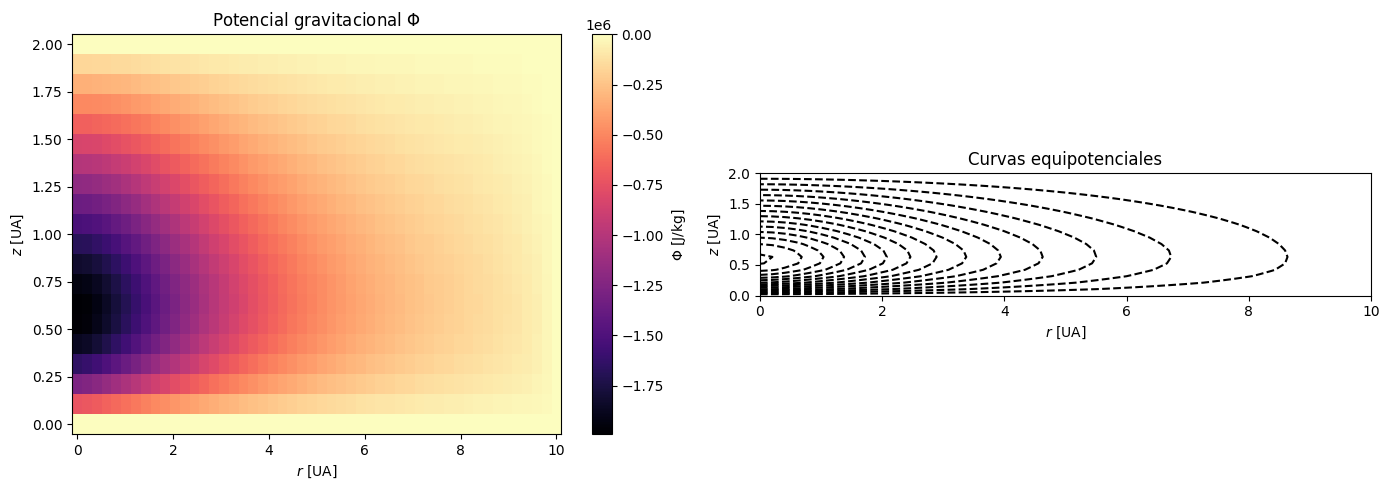

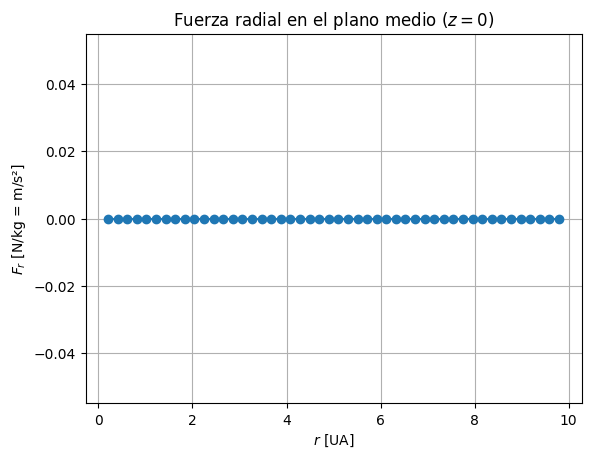

In [18]:
#  Gráfica de Φ y curvas equipotenciales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de color de Phi (escala en SI, valores muy pequeños)
pc = axes[0].pcolormesh(R/AU, Z/AU, Phi_sor, cmap='magma', shading='auto')
axes[0].set_title(r'Potencial gravitacional $\Phi$')
axes[0].set_xlabel(r'$r$ [UA]')
axes[0].set_ylabel(r'$z$ [UA]')
fig.colorbar(pc, ax=axes[0], label=r'$\Phi$ [J/kg]')

# Equipotenciales (algunos niveles)
niveles = np.linspace(np.min(Phi_sor[1:,1:]), np.max(Phi_sor[1:,1:]), 15)
axes[1].contour(R/AU, Z/AU, Phi_sor, levels=niveles, colors='k')
axes[1].set_title('Curvas equipotenciales')
axes[1].set_xlabel(r'$r$ [UA]')
axes[1].set_ylabel(r'$z$ [UA]')
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

# Fuerza radial Fr = -∂Φ/∂r
Fr = np.zeros_like(Phi_sor)
# Diferencias centradas en puntos interiores (i=1..Nr-2)
for i in range(1, Nr-1):
    for j in range(Nz):
        Fr[i, j] = -(Phi_sor[i+1, j] - Phi_sor[i-1, j]) / (2 * dr)
# En el eje (i=0) por simetría Fr=0
# En el borde exterior (i=Nr-1) no se calcula (se deja 0)

# Perfil de Fr en el plano medio (z=0)
j_mid = 0  # z=0 corresponde al primer índice
plt.figure()
plt.plot(r[1:-1]/AU, Fr[1:-1, j_mid], 'o-')
plt.xlabel(r'$r$ [UA]')
plt.ylabel(r'$F_r$ [N/kg = m/s²]')
plt.title('Fuerza radial en el plano medio ($z=0$)')
plt.grid()
plt.show()

Masa total del disco ≈ 2.184e+29 kg


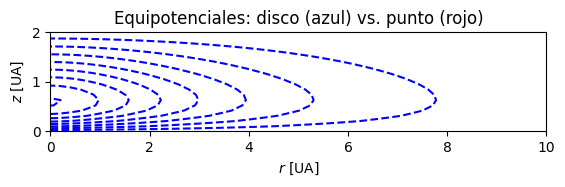

In [19]:
# Masa total del disco (mitad superior e inferior)
dA = dr * dz
M_disk = 4 * np.pi * np.sum(r[:, np.newaxis] * rho) * dA
print(f"Masa total del disco ≈ {M_disk:.3e} kg")

# Potencial de punto: Φ_pt = -G*M / sqrt(r^2 + z^2)
# Evitar división por cero en r=0,z=0
R_sq = R**2 + Z**2
Phi_pt = np.zeros_like(R)
mask = R_sq > 0
Phi_pt[mask] = -G * M_disk / np.sqrt(R_sq[mask])

# Graficar comparación de equipotenciales
fig, ax = plt.subplots()
# Niveles normalizados para comparar formas
niveles_rel = np.linspace(-1, -0.1, 8)  # negativos, fracción del valor máximo
vmax = np.max(np.abs(Phi_sor[1:,1:]))
contour1 = ax.contour(R/AU, Z/AU, Phi_sor / vmax, levels=niveles_rel, colors='blue')
contour2 = ax.contour(R/AU, Z/AU, Phi_pt / np.min(Phi_pt), levels=niveles_rel, colors='red', linestyles='--')
ax.set_xlabel(r'$r$ [UA]')
ax.set_ylabel(r'$z$ [UA]')
ax.set_title('Equipotenciales: disco (azul) vs. punto (rojo)')
ax.set_aspect('equal')
plt.show()

## Comparación cualitativa y discusión del perfil kepleriano

### Equipotenciales del disco frente al potencial de punto

La solución numérica del potencial gravitacional $(\Phi(r,z))$ generado por el disco muestra equipotenciales claramente **achatadas** hacia el plano medio \(z=0\) en comparación con las esferas concéntricas que produciría una masa puntual equivalente $(M_{\text{disco}})$.  
Este aplanamiento es una consecuencia directa de la distribución extensa de materia: la gravedad en las regiones cercanas al disco “siente” más masa en la dirección radial que en la vertical, lo que deforma las superficies de potencial constante, estirándolas a lo largo del plano del disco.

En la gráfica superpuesta, las líneas azules (disco) se separan de las rojas (punto) especialmente en las zonas altas $((z \gtrsim 0.5) UA)$ y en los bordes exteriores del disco. Cerca del eje $((r \ll z))$ ambas soluciones tienden a coincidir porque la contribución dominante proviene de las partes más internas, que se comportan aproximadamente como una fuente puntual.

### Fuerza radial y consistencia con rotación kepleriana
